# Evaluation of the module `pyzx.boolean_logic`

In this notebook, we evaluate the core functionality of the module `pyzx.boolean_logic` by running a population of test cases.
Once a population of boolean formulas is generated, from each formula one test case is created.
The test cases are then executed, running through the following steps:
1. Construct a ZH-diagram from the formula and compare its corresponding matrix to that of the original formula.
2. Simplify the ZH-diagram using the simplification functionalities of PyZX and compare the resulting matrix to that of the original formula.
3. (Once implemented: Extract a quantum circuit from the simplified ZH-diagram and compare its corresponding matrix to that of the original formula.)

The evaluation results are written to a JSON file, which can be used for further analysis and visualization.

In [1]:
import sys; sys.path.append('../../..')
from pprint import pp
from pathlib import Path
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt

from pyzx.boolean_logic.tests.evaluation import (
    Evaluation, TestCase, TestResult, TEST_RESULT_MIN, TEST_RESULT_MAX
)
from pyzx.boolean_logic.expression import SymPyBooleanExpression
import pyzx.boolean_logic.tests.helper as h

In [2]:
num_cases, num_vars, seed = 2000, 10, 1234
results_dir = Path(f'./results/{num_cases}-{num_vars}-{seed}/')
results_path = results_dir / 'results.json'

## Test Execution

In [3]:
eva = Evaluation()
eva.gen_population(
    num_cases=num_cases, num_vars=num_vars,
    grammar=SymPyBooleanExpression.EBNF_GRAMMAR_TEMPLATE_PREFIX,
    seed=seed, verbosity=2
)

Generating population with 2000 cases and 10 variables
	Generating grammar in BNF form
Fuzzer generating test case 2000 of 2000... All expansions covered. Duplicating context of <func> 1 time and incrementing interval bounds of nonterminals to (2, 9)
Generated 2000 test cases in 3527 fuzzes, 57% efficiency


In [4]:
eva.print_population()

[
'~x_8'
'x_1'
'(x_2 | x_9) ^ (x_4 & x_5 & x_9 & (x_2 ^ x_7))'
'x_1 ^ x_4'
'x_2 & x_6 & x_7 & ~x_5 & (x_0 | (x_2 & x_8 & x_9))'
'x_3 & x_5 & x_6'
'x_0 ^ x_2 ^ x_3 ^ x_4 ^ x_7 ^ x_9'
'x_5 & x_7'
'x_1 | x_4'
'x_6 | (x_1 & x_3 & x_4 & x_7 & ~x_4 & ~x_7 & ~(x_7 ^ ~x_0))'
'x_3 ^ x_7 ^ ~(x_8 | (x_0 & x_5)) ^ ~(x_9 ^ ~x_0 ^ ~x_7)'
'~(x_6 & x_9) ^ (x_2 & x_4 & x_7 & ~x_8)'
'x_1 ^ (x_9 & ~x_3)'
'x_0 | x_3 | x_7 | ~x_6 | ~x_8 | ~x_9 | (x_6 & x_8 & ~x_4) | ~(x_5 ^ x_7 ^ x_8 ^ (x_8 | (x_0 ^ x_3)) ^ (x_5 | x_6 | (x_4 & x_5 & x_8)))'
'x_3 | ~x_0'
'~x_1 ^ ~x_7'
'(x_6 & x_9) ^ (x_5 & x_8 & ~x_2 & ~x_9)'
'~x_4 & (x_8 ^ ~x_1 ^ (x_0 & ~x_8) ^ (x_1 | x_2 | x_3) ^ (x_3 | x_4 | x_7 | x_9 | (x_3 & x_4 & x_5)))'
'x_0 | x_3 | x_4 | ~x_7 | (x_7 & (x_1 ^ x_9))'
'(x_4 ^ x_5 ^ ~x_8) & ~(x_2 & x_5 & ~x_3 & ~x_7)'
'x_5 & x_7 & x_9 & ~(x_7 & (x_6 ^ (x_6 & x_9))) & (x_7 | (x_0 ^ x_2 ^ x_3 ^ x_7 ^ ~x_1))'
'x_1 & x_5 & ~x_1 & ~x_6 & (x_7 | x_9) & ~(x_3 ^ x_8)'
'x_2 & x_5 & ~x_9'
'~x_6 | (x_1 & x_2 & x_4 & x_6 & x_7)'
'x

In [5]:
eva(verbosity=2, step_timeout_limit_ms=12000)
summary = eva.result_summary(results_path)

Running evaluation with 2000 test cases

(1/2000) Running test case: ~x_8
	Running step 1: create_zh
	Asserting result
	Running step 2: simplify
	Asserting result
Test result: PASS

(2/2000) Running test case: x_1
	Running step 1: create_zh
	Asserting result
	Running step 2: simplify
	Asserting result
Test result: PASS

(3/2000) Running test case: (x_2 | x_9) ^ (x_4 & x_5 & x_9 & (x_2 ^ x_7))
	Running step 1: create_zh
	Asserting result
	Running step 2: simplify
	Asserting result
Test result: PASS

(4/2000) Running test case: x_1 ^ x_4
	Running step 1: create_zh
	Asserting result
	Running step 2: simplify
	Asserting result
Test result: PASS

(5/2000) Running test case: x_2 & x_6 & x_7 & ~x_5 & (x_0 | (x_2 & x_8 & x_9))
	Running step 1: create_zh
	Asserting result
	Running step 2: simplify
	Asserting result
Test result: PASS

(6/2000) Running test case: x_3 & x_5 & x_6
	Running step 1: create_zh
	Asserting result
	Running step 2: simplify
	Asserting result
Test result: PASS

(7/2000) Ru

## Result Analysis

Run the following cell to retrieve the evaluation results from the JSON file.

In [3]:
eva = Evaluation.from_summary(results_path)
summary = eva.result_summary()

### Plots

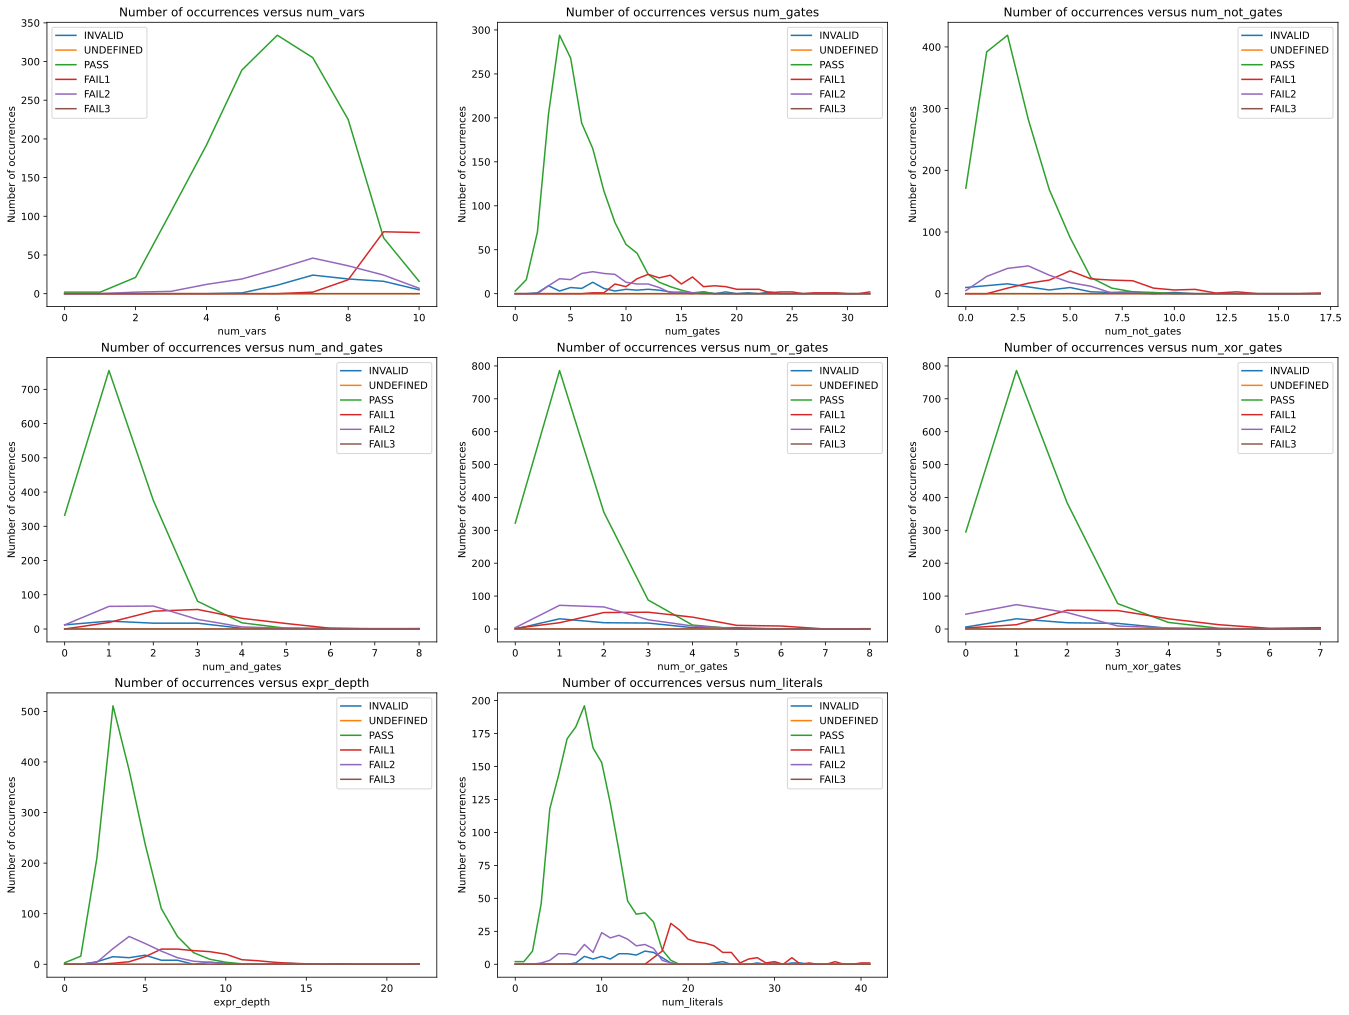

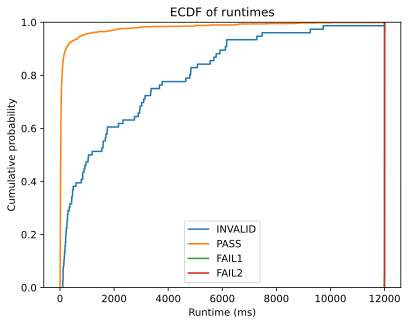

In [4]:
result_to_metric = summary['result_to_metric']
runtimes = summary['timing']['result_to_runtime']
result_names = [result.name for result in TestResult]

composed_fig, axes = h.plot_composed_metric_counts(
    result_to_metric,
    result_names,
#    filepath=results_dir / 'composed.png'
)
fig_ax_pairs = h.plot_multiple_metric_counts(
    result_to_metric,
    result_names,
#    filepath=results_dir / '{metric}.png'
)
for fig, _ in fig_ax_pairs:
    plt.close(fig)

fig_rt, ax_rt = h.plot_runtimes_ecdf_fig(
    runtimes,
    result_names,
#    filepath=results_dir / 'runtimes.png'
)

### Inspecting the runtimes

We determine the fraction of test cases that successfully completed each step of the workflow within 5 seconds.

In [7]:
num_5s = eva.filter_test_cases(
    test_result=[TestResult.PASS, TestResult.FAIL1, TestResult.FAIL2, TestResult.FAIL3],
    runtime={'1': (None, 4999), '2': (None, 4999), '3': (None, 4999)}
)
frac_of_total = int(100 * len(num_5s) / len(eva.population))
num_valid = len(eva.population) - len(eva.filter_test_cases(test_result=TestResult.INVALID))
frac_of_valid = int(100 * len(num_5s) / num_valid)
print(f'Number of valid test cases where each executed step took at most 5 seconds:\n{len(num_5s)}'
    f'\nFraction of total population:\n{frac_of_total}%\nFraction of valid test cases:\n'
    f'{frac_of_valid}% (of {num_valid})\n'
)

pass_5s = eva.filter_test_cases(
    test_result=TestResult.PASS,
    runtime={'1': (None, 4999), '2': (None, 4999), '3': (None, 4999)}
)
frac_pass_of_total = int(100 * len(pass_5s) / len(eva.population))
num_pass = len(eva.filter_test_cases(test_result=TestResult.PASS))
frac_of_pass = int(100 * len(pass_5s) / num_pass)
print(f'Number of test cases that passed where each executed step took at most 5 seconds:\n{len(pass_5s)}'
    f'\nFraction of total population:\n{frac_pass_of_total}%\nFraction of passing test cases:\n'
    f'{frac_of_pass}% (of {num_pass})'
)

Number of valid test cases where each executed step took at most 5 seconds:
1521
Fraction of total population:
76%
Fraction of valid test cases:
79% (of 1924)

Number of test cases that passed where each executed step took at most 5 seconds:
1521
Fraction of total population:
76%
Fraction of passing test cases:
97% (of 1564)


We additionally output those test cases that passed but did not satisfy the runtime constraint.

In [10]:
pass_no_5s_1 = eva.filter_test_cases(
    test_result=TestResult.PASS,
    runtime={'1': (5000, None)}
)
print(f'Test cases that took more than 5 seconds at ``create_zh`` ({len(pass_no_5s_1)}):')
pp(pass_no_5s_1)
pass_no_5s_2 = eva.filter_test_cases(
    test_result=TestResult.PASS,
    runtime={'2': (5000, None)}
)
print(f'\nTest cases that took more than 5 seconds at ``simplify`` ({len(pass_no_5s_2)}):')
pp(pass_no_5s_2)

Test cases that took more than 5 seconds at ``create_zh`` (26):
[(71,
  TestCase(x_2 & x_4 & ~(x_0 & x_3 & ~x_9) & ~(x_8 ^ (x_6 | ((x_3 | x_7) ^ (x_0 & (x_0 | x_3) & (x_1 | x_6 | x_7))))))),
 (113,
  TestCase(x_3 & x_9 & (x_5 | x_7) & (x_2 | (x_0 ^ x_7 ^ ~x_5 ^ (x_2 | x_8) ^ ~(x_0 ^ x_7) ^ ~(x_2 | ~(x_1 ^ x_2) | ~(x_5 ^ x_8)))))),
 (174,
  TestCase(x_1 & x_5 & x_8 & (x_7 ^ ~x_2 ^ (x_1 | x_2 | x_4 | x_5 | x_6 | x_9 | ~x_9 | ~(x_2 & x_4 & x_5 & x_9 & (x_7 ^ ~x_6)))))),
 (193,
  TestCase(x_4 ^ x_5 ^ ~(x_2 | x_6 | ~x_0 | (~x_4 & (x_1 ^ x_2 ^ x_3 ^ x_4 ^ x_5 ^ x_6 ^ x_8 ^ x_9 ^ ~x_4 ^ ~x_9))))),
 (302,
  TestCase(x_6 & (x_1 ^ x_2 ^ x_5 ^ x_9 ^ (x_2 & x_8 & x_9 & ~x_0 & ~x_9 & (x_1 | x_3) & (x_4 | x_5 | (x_2 & x_7)))))),
 (412,
  TestCase(x_0 & x_4 & x_6 & ~x_9 & (x_6 ^ x_8 ^ ~x_5) & (x_6 ^ (x_0 | x_1 | x_3 | x_7 | x_9 | ~x_2 | ~x_3)))),
 (452,
  TestCase(~x_6 ^ ~(x_9 ^ ~x_9) ^ (~x_7 | ((x_6 & ~x_4) ^ (x_3 & x_5 & x_7 & (x_1 | x_2 | x_4 | (x_4 & ~x_0 & ~(x_5 ^ x_7)))))))),
 (615,
  TestCase(

### Inspecting particular test cases

Let us inspect a number of failed test cases to deduce potential causes for the failures.
First, we print their associated boolean expressions.

In [ ]:
print('Test cases that failed at ``create_zh``:')
failed1 = eva.filter_test_cases(test_result=TestResult.FAIL1)
pp(failed1[:20])

print('\nTest cases that failed at ``simplify``:')
failed2 = eva.filter_test_cases(test_result=TestResult.FAIL2)
pp(failed2[:20])

Test cases that failed at ``create_zh``:
[(13,
  TestCase(x_0 | x_3 | x_7 | ~x_6 | ~x_8 | ~x_9 | (x_6 & x_8 & ~x_4) | ~(x_5 ^ x_7 ^ x_8 ^ (x_8 | (x_0 ^ x_3)) ^ (x_5 | x_6 | (x_4 & x_5 & x_8))))),
 (60,
  TestCase(x_0 ^ x_2 ^ x_4 ^ x_8 ^ ~x_9 ^ (x_2 & x_6 & ~(x_1 ^ x_3 ^ x_9 ^ (x_2 | (x_2 ^ x_9) | (x_2 & x_4 & x_6 & (x_0 | x_1 | x_2))))))),
 (68,
  TestCase(x_1 & x_4 & x_5 & x_6 & x_9 & ~(x_1 & x_2) & (x_0 | x_3 | x_8 | ~x_3 | ~(x_8 ^ x_9) | (x_3 & x_9 & ~x_7 & ~x_8 & (x_2 | x_3 | x_6 | (x_0 & x_2)))))),
 (125,
  TestCase(x_5 ^ x_7 ^ ~(x_1 & ~x_6 & (x_1 ^ x_4 ^ x_9)) ^ (x_1 & x_2 & x_5 & x_6 & x_8 & x_9 & (x_3 ^ x_4) & ~(x_2 & x_4 & x_8) & (x_6 | ~(x_1 | x_2 | x_6))))),
 (139,
  TestCase(~x_6 ^ ~(x_1 | x_6 | (x_2 ^ x_8 ^ x_9 ^ ~x_6 ^ ~x_8)) ^ (x_2 & x_3 & (x_5 | x_6 | ~x_3 | ~x_5 | ~(x_1 ^ x_2 ^ x_5 ^ x_7))))),
 (144,
  TestCase(x_3 & x_5 & ~(x_0 | x_2 | ~x_3) & (x_3 | x_6 | x_7 | ((x_4 | ~x_0 | ~(x_1 ^ ~x_5)) & (x_1 ^ x_2 ^ x_9 ^ ~x_9 ^ (x_3 | ~x_7 | ~x_8 | ~(x_6 | ~(x_2 & x_4 & x_9 & 

Additionally, we can visualize the test cases to inspect their ZH-diagrams and their associated matrices, if present.
We visualize the first ten test cases that failed during the creation of the ZH-diagram.

Running test case: x_0 | x_3 | x_7 | ~x_6 | ~x_8 | ~x_9 | (x_6 & x_8 & ~x_4) | ~(x_5 ^ x_7 ^ x_8 ^ (x_8 | (x_0 ^ x_3)) ^ (x_5 | x_6 | (x_4 & x_5 & x_8)))
	Running step 1: create_zh
	Timeout after 10000 milliseconds during create_zh
Test result: FAIL1



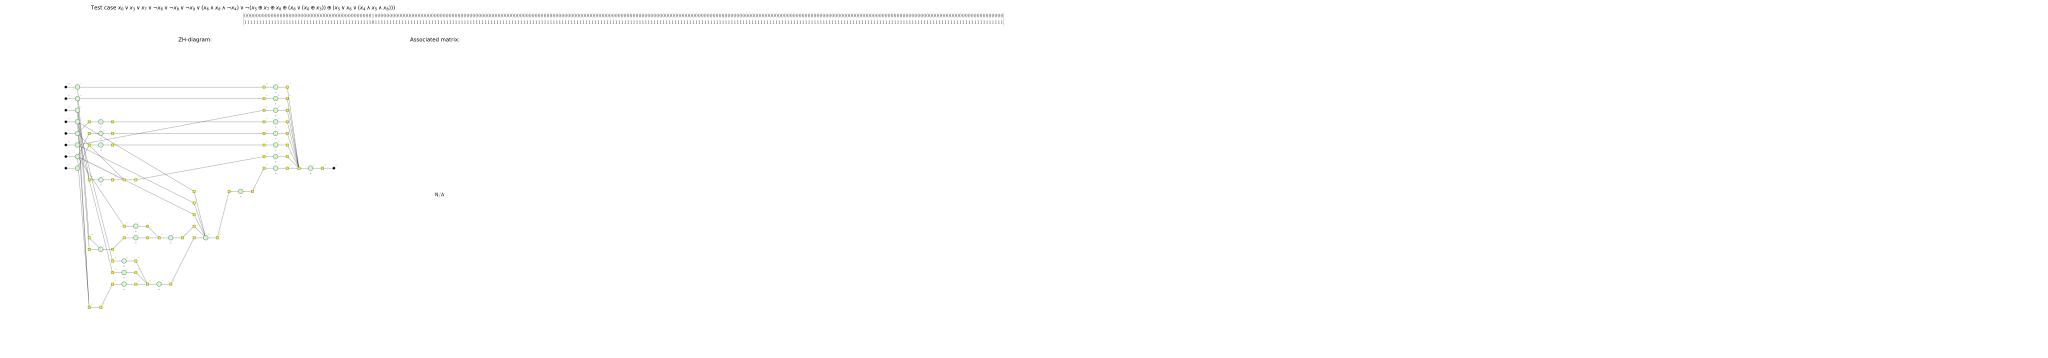

Running test case: x_0 ^ x_2 ^ x_4 ^ x_8 ^ ~x_9 ^ (x_2 & x_6 & ~(x_1 ^ x_3 ^ x_9 ^ (x_2 | (x_2 ^ x_9) | (x_2 & x_4 & x_6 & (x_0 | x_1 | x_2)))))
	Running step 1: create_zh
	Timeout after 10000 milliseconds during create_zh
Test result: FAIL1



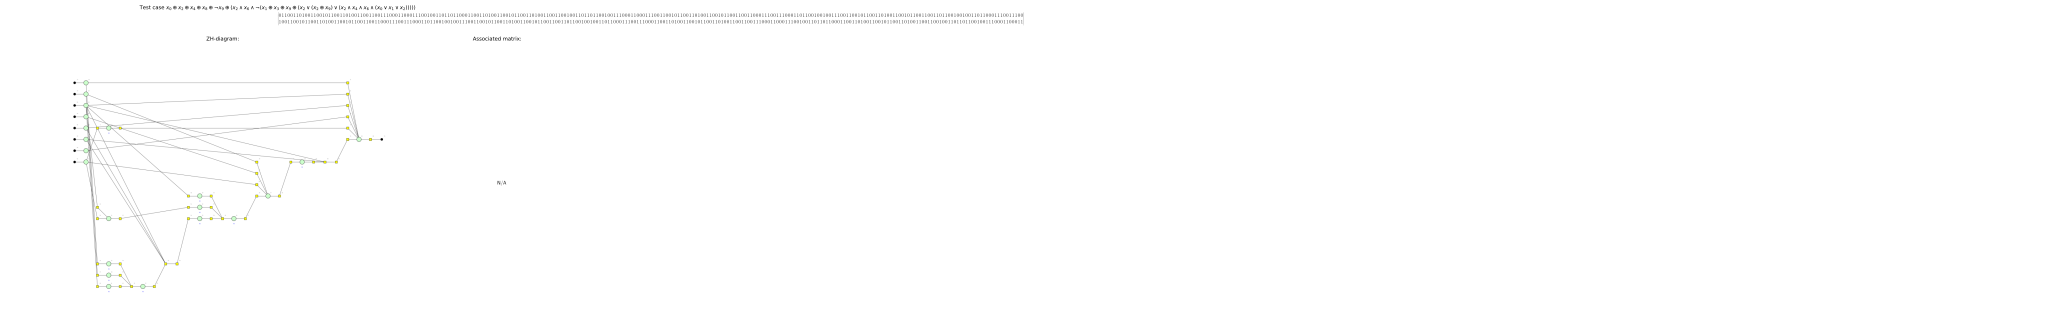

Running test case: x_1 & x_4 & x_5 & x_6 & x_9 & ~(x_1 & x_2) & (x_0 | x_3 | x_8 | ~x_3 | ~(x_8 ^ x_9) | (x_3 & x_9 & ~x_7 & ~x_8 & (x_2 | x_3 | x_6 | (x_0 & x_2))))
	Running step 1: create_zh
	Timeout after 10000 milliseconds during create_zh
Test result: FAIL1



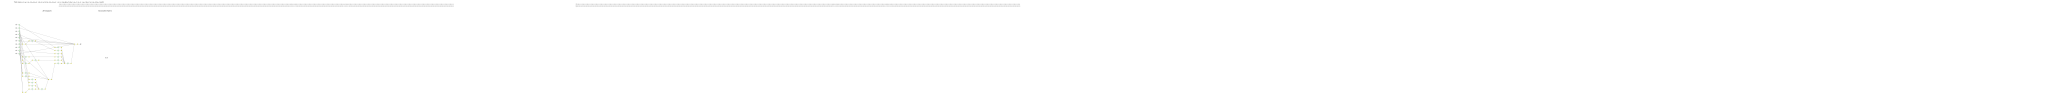

Running test case: x_5 ^ x_7 ^ ~(x_1 & ~x_6 & (x_1 ^ x_4 ^ x_9)) ^ (x_1 & x_2 & x_5 & x_6 & x_8 & x_9 & (x_3 ^ x_4) & ~(x_2 & x_4 & x_8) & (x_6 | ~(x_1 | x_2 | x_6)))
	Running step 1: create_zh
	Timeout after 10000 milliseconds during create_zh
Test result: FAIL1



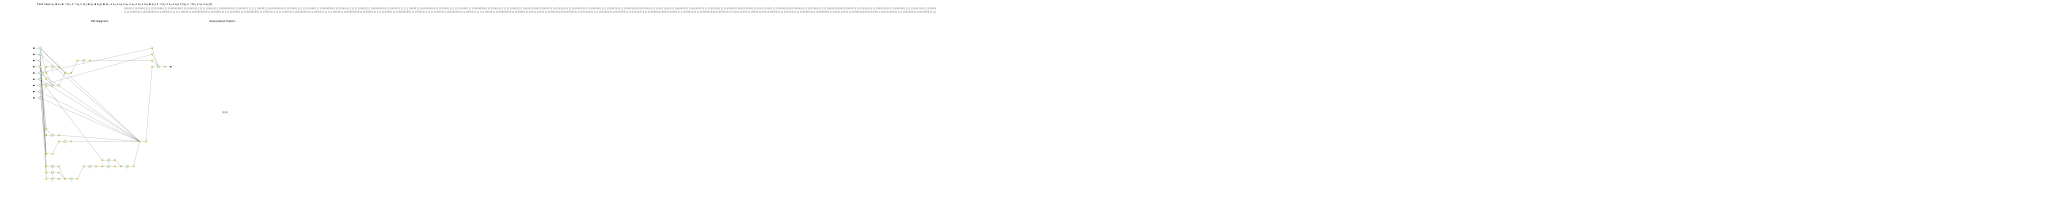

Running test case: ~x_6 ^ ~(x_1 | x_6 | (x_2 ^ x_8 ^ x_9 ^ ~x_6 ^ ~x_8)) ^ (x_2 & x_3 & (x_5 | x_6 | ~x_3 | ~x_5 | ~(x_1 ^ x_2 ^ x_5 ^ x_7)))
	Running step 1: create_zh
	Timeout after 10000 milliseconds during create_zh
Test result: FAIL1



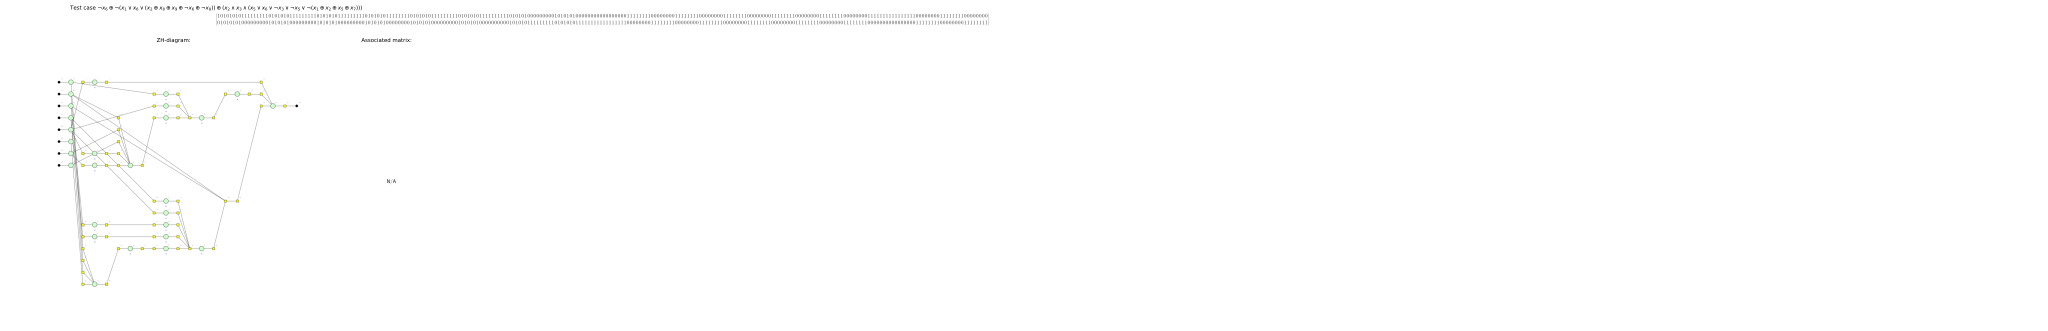

Running test case: x_3 & x_5 & ~(x_0 | x_2 | ~x_3) & (x_3 | x_6 | x_7 | ((x_4 | ~x_0 | ~(x_1 ^ ~x_5)) & (x_1 ^ x_2 ^ x_9 ^ ~x_9 ^ (x_3 | ~x_7 | ~x_8 | ~(x_6 | ~(x_2 & x_4 & x_9 & (x_3 ^ x_7 ^ (x_9 & ~x_4) ^ (x_4 & (x_0 ^ x_1)))))))))
	Running step 1: create_zh
	Timeout after 10000 milliseconds during create_zh
Test result: FAIL1



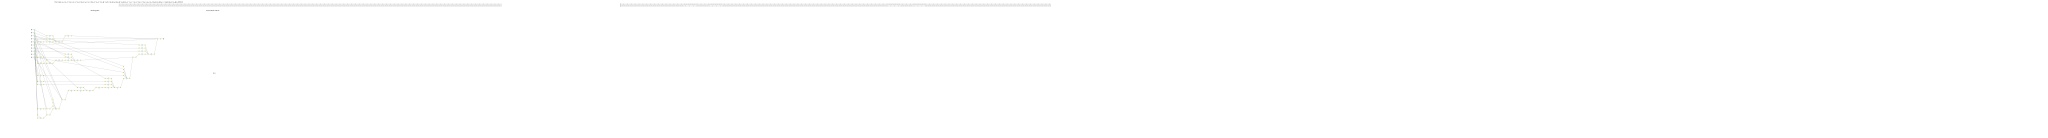

Running test case: x_4 & x_9 & ~(x_8 ^ (x_7 | ~x_5 | ~(x_1 & x_8) | ~(x_3 & x_9) | (x_1 & x_2 & x_6 & (x_7 ^ x_8 ^ ~x_3) & (x_1 | x_7 | ~x_7 | (x_1 & x_2 & (~x_1 ^ ~(x_0 ^ x_4)))))))
	Running step 1: create_zh
	Timeout after 10000 milliseconds during create_zh
Test result: FAIL1



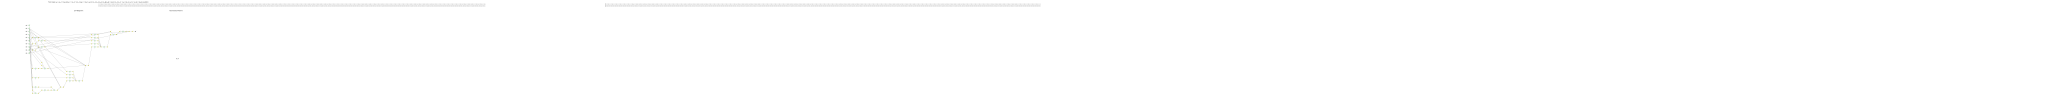

Running test case: x_1 & ~x_5 & ~x_9 & ~(x_0 & x_1 & x_7 & x_9 & (x_0 ^ x_1) & (x_4 ^ x_9)) & (x_8 | ~(x_3 & ~x_5 & (x_2 ^ x_9 ^ ~x_1 ^ (x_4 | x_5))))
	Running step 1: create_zh
	Timeout after 10000 milliseconds during create_zh
Test result: FAIL1



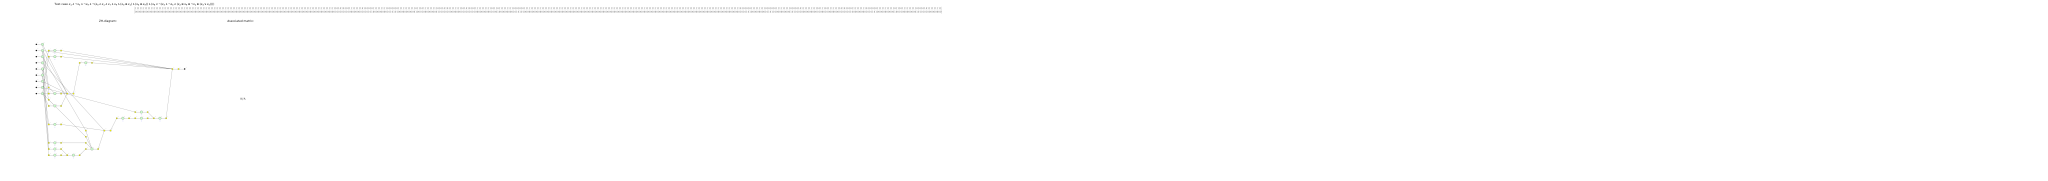

Running test case: x_6 ^ ~x_4 ^ ~(x_2 & x_4 & x_7 & x_8 & x_9) ^ ~(x_3 | (~(x_6 & x_7 & x_8 & ~x_0 & ~x_7) ^ ~(x_1 & x_9 & (x_3 | x_4 | x_6 | x_7 | x_9))))
	Running step 1: create_zh
	Timeout after 10000 milliseconds during create_zh
Test result: FAIL1



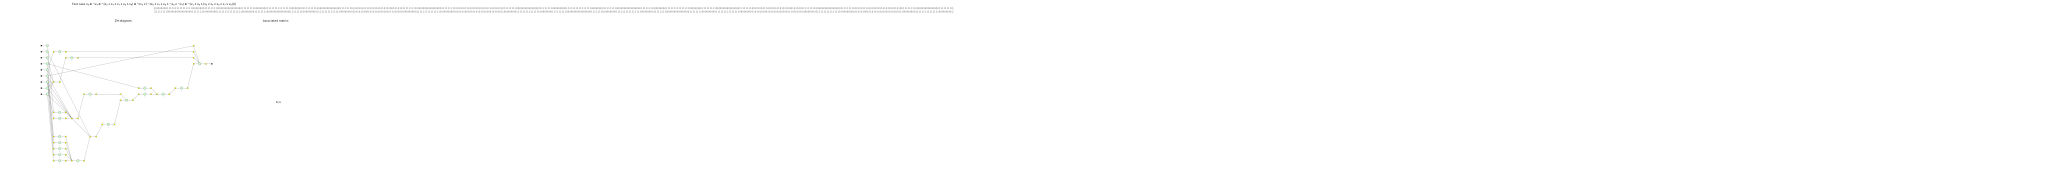

Running test case: x_2 & ~x_3 & (x_0 ^ x_6) & ~(x_0 | x_3 | x_4 | ~(x_4 & x_8 & (x_1 | x_8 | ~x_6 | (x_2 & ~x_7) | ~(x_4 & ~x_6 & ~(x_1 ^ x_5) & (x_0 | x_1 | x_2 | x_3 | x_5)))))
	Running step 1: create_zh
	Timeout after 10000 milliseconds during create_zh
Test result: FAIL1



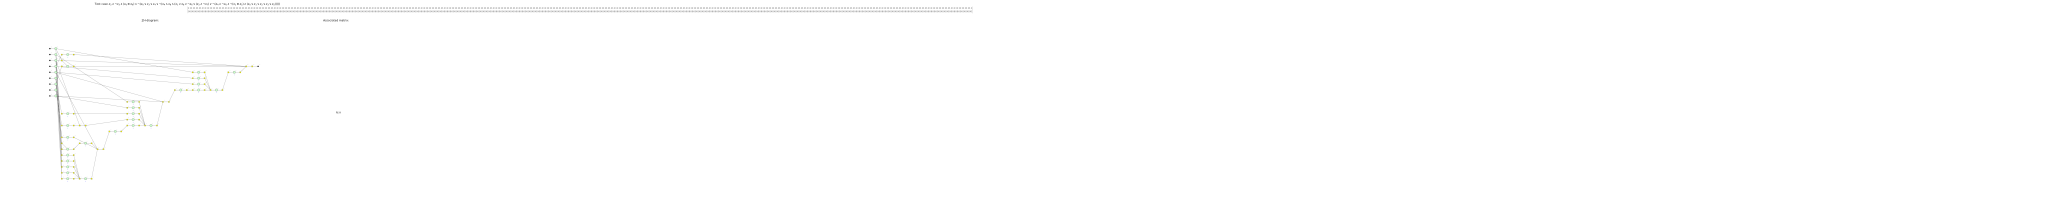

In [5]:
for i, tc in failed1[:10]:
    tc(2)
    fig = tc.draw()
    display(fig)
    plt.close(fig)

The following cell draws some of the ZH-diagrams that caused timeouts during their simplification.

Running test case: x_6 | (x_1 & x_3 & x_4 & x_7 & ~x_4 & ~x_7 & ~(x_7 ^ ~x_0))
	Running step 1: create_zh
	Asserting result
	Running step 2: simplify
	Timeout after 10000 milliseconds during simplify
Test result: FAIL2



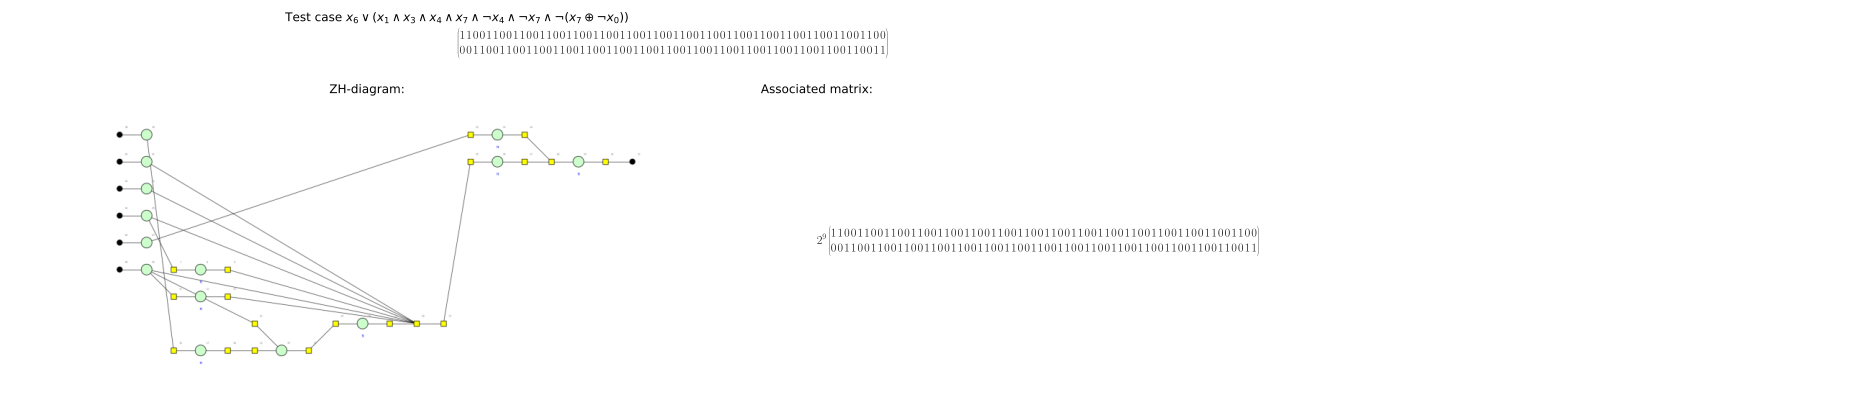

Running test case: ~x_4 & (x_8 ^ ~x_1 ^ (x_0 & ~x_8) ^ (x_1 | x_2 | x_3) ^ (x_3 | x_4 | x_7 | x_9 | (x_3 & x_4 & x_5)))
	Running step 1: create_zh
	Asserting result
	Running step 2: simplify
	Timeout after 10000 milliseconds during simplify
Test result: FAIL2



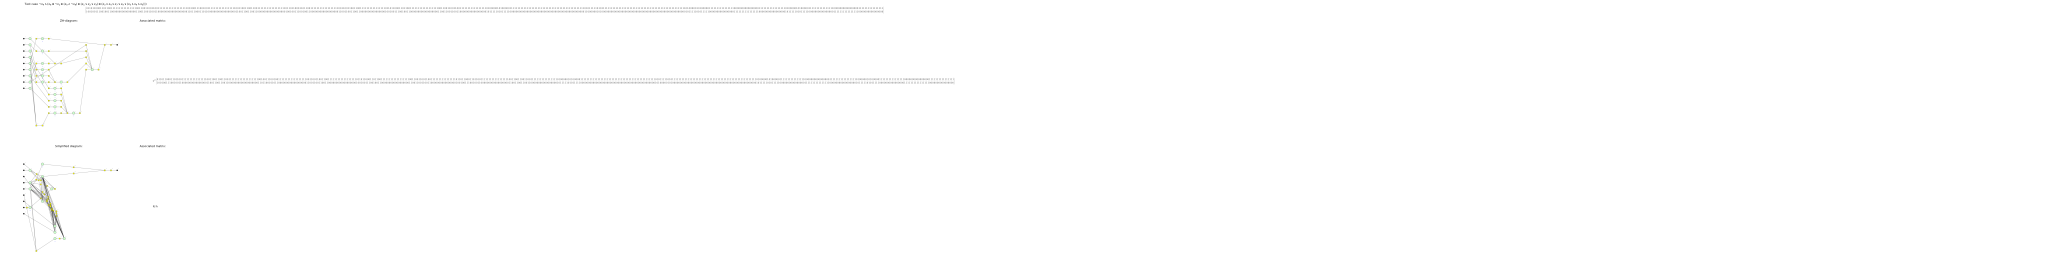

Running test case: x_4 & x_6 & x_8 & (x_1 | x_5 | x_6 | ~x_6)
	Running step 1: create_zh
	Asserting result
	Running step 2: simplify
	Timeout after 10000 milliseconds during simplify
Test result: FAIL2



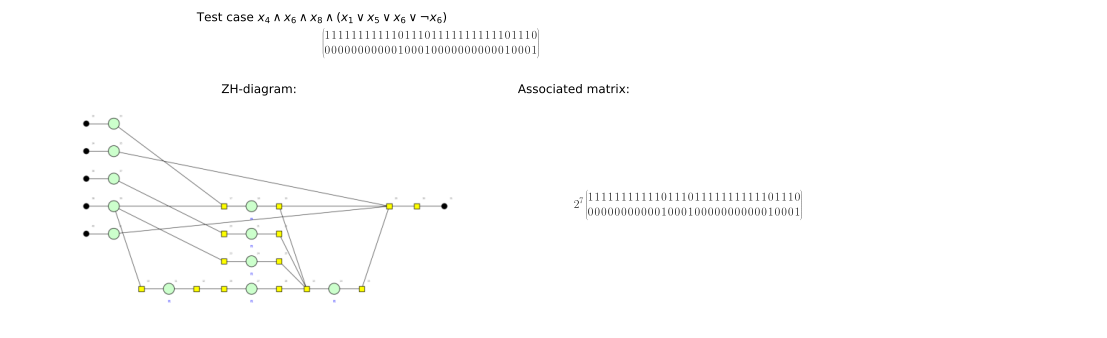

Running test case: x_9 | (x_1 & x_2 & x_3 & x_4 & x_5 & x_8 & ~x_1 & ~x_3 & ~x_9)
	Running step 1: create_zh
	Asserting result
	Running step 2: simplify
	Timeout after 10000 milliseconds during simplify
Test result: FAIL2



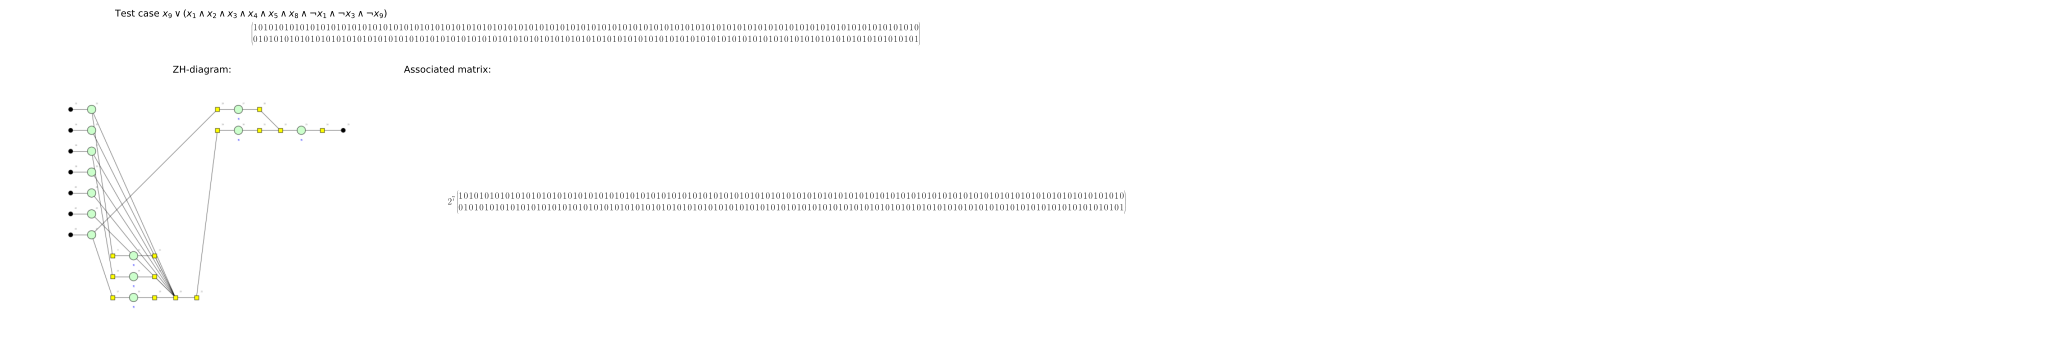

Running test case: x_2 ^ x_6 ^ x_8 ^ x_9 ^ ~x_8 ^ (x_2 | x_3 | x_6 | x_7)
	Running step 1: create_zh
	Asserting result
	Running step 2: simplify
	Timeout after 10000 milliseconds during simplify
Test result: FAIL2



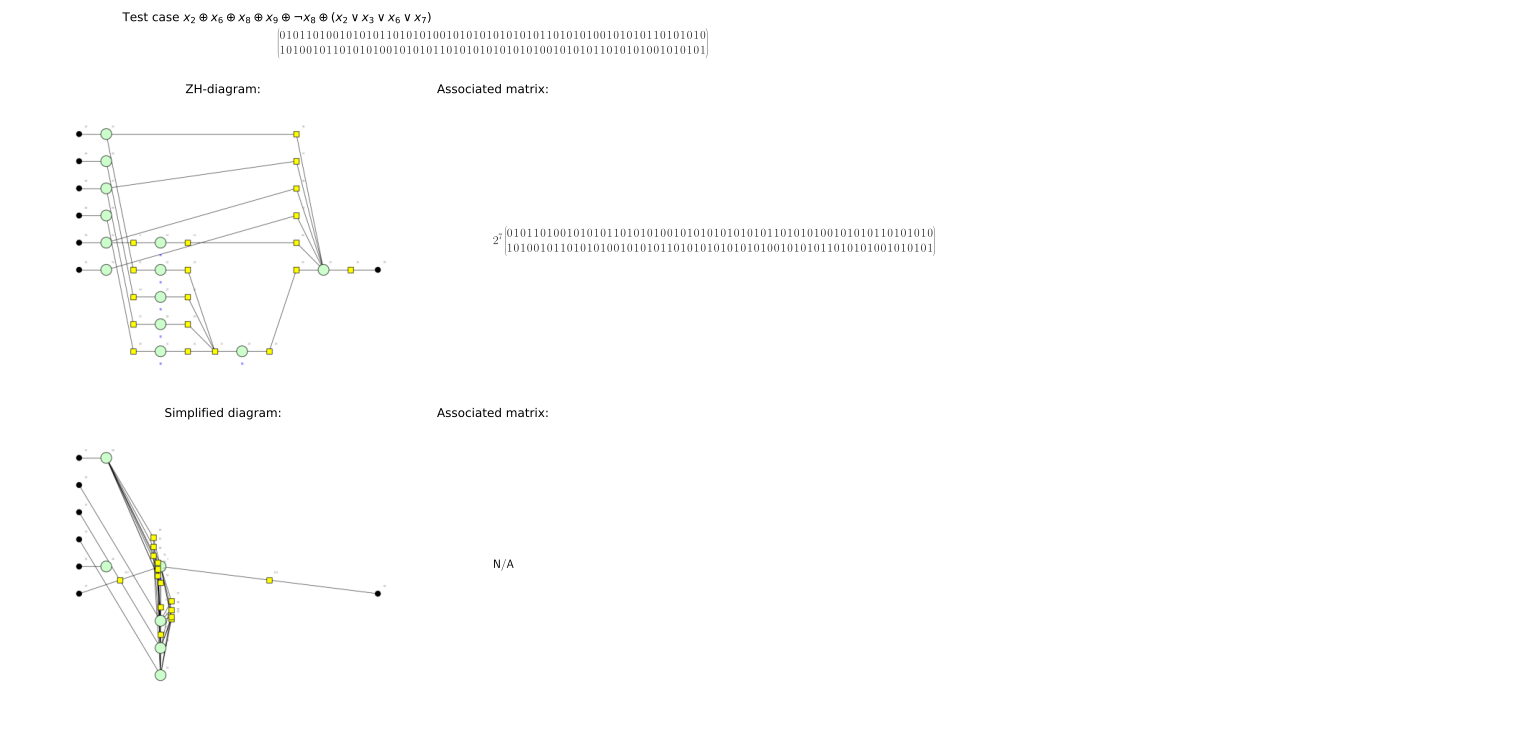

Running test case: x_3 & x_9 & ~(x_1 | x_5) & (x_0 | x_2 | x_6 | x_7 | ~x_7)
	Running step 1: create_zh
	Asserting result
	Running step 2: simplify
	Timeout after 10000 milliseconds during simplify
Test result: FAIL2



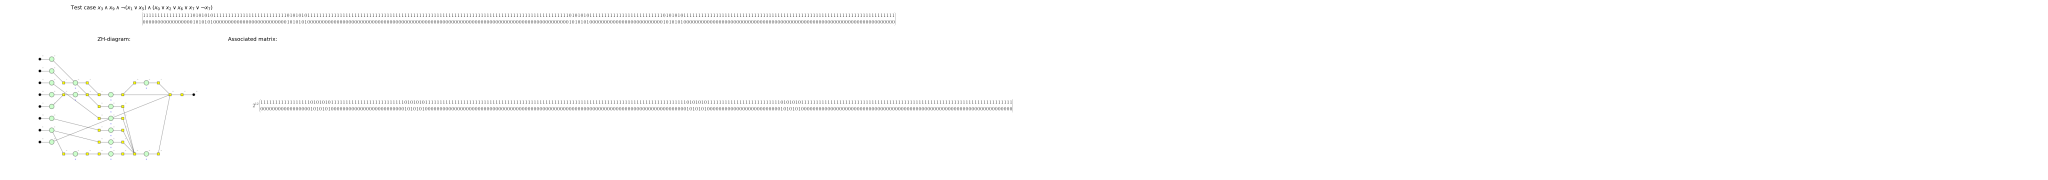

Running test case: x_7 | x_9 | (x_5 & x_6) | (x_1 & x_3 & x_9 & ~x_7) | (x_2 & x_8 & x_9 & ~x_8 & (x_9 ^ ~x_8))
	Running step 1: create_zh
	Asserting result
	Running step 2: simplify
	Timeout after 10000 milliseconds during simplify
Test result: FAIL2



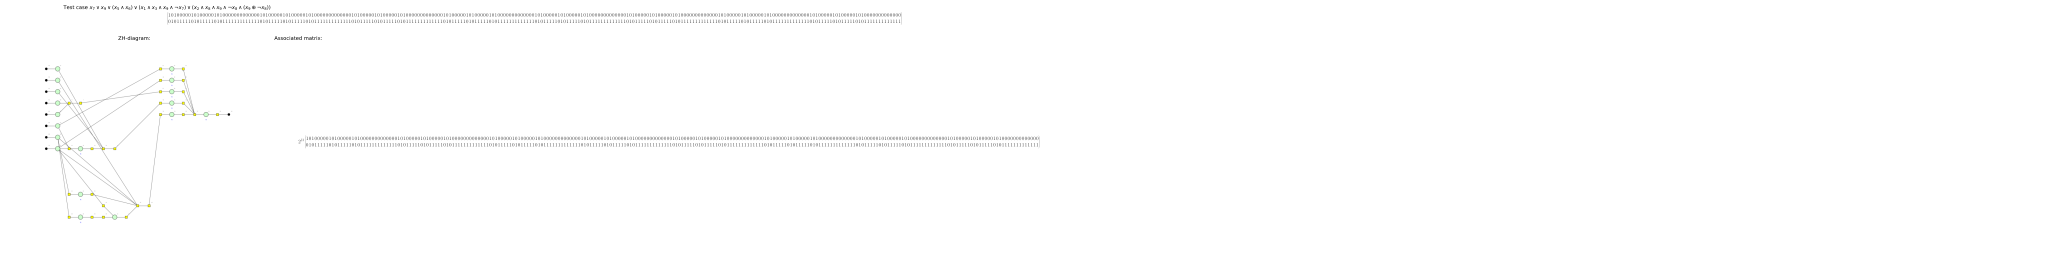

Running test case: x_5 | (x_5 & ~x_5) | (x_6 ^ ~x_1) | ~(x_8 & ~x_7)
	Running step 1: create_zh
	Asserting result
	Running step 2: simplify
	Timeout after 10000 milliseconds during simplify
Test result: FAIL2



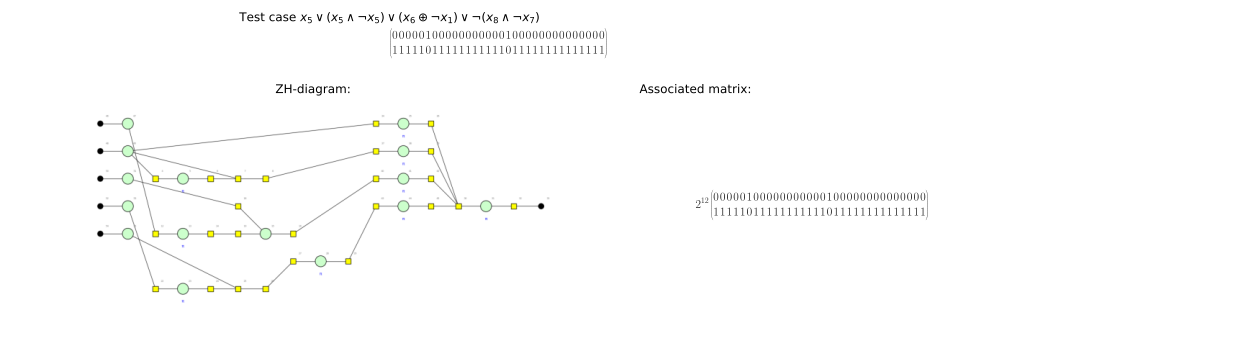

Running test case: x_5 | x_9 | ~x_4 | (x_2 ^ ~(x_4 & (x_4 ^ x_9) & ((x_0 & x_5) ^ (x_4 | x_7))))
	Running step 1: create_zh
	Asserting result
	Running step 2: simplify
	Timeout after 10000 milliseconds during simplify
Test result: FAIL2



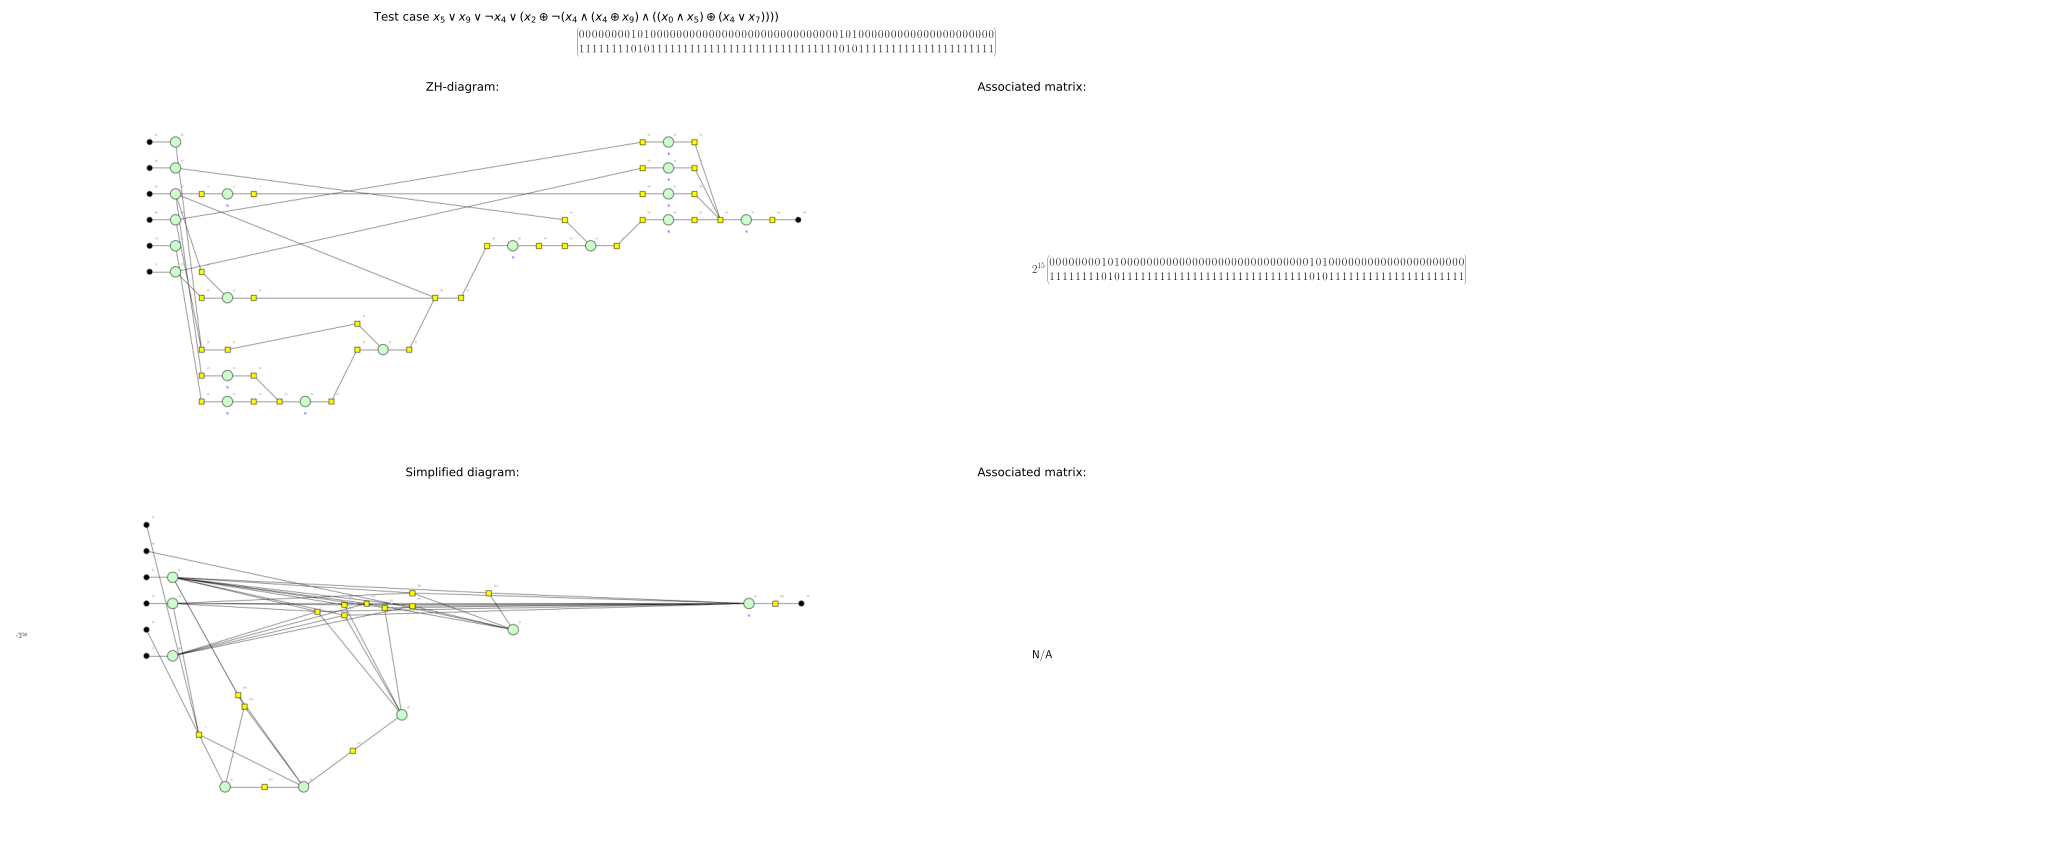

Running test case: x_7 | ~(x_0 | x_1 | x_4 | (x_4 ^ x_8) | (x_0 & x_1 & x_8 & ~x_8))
	Running step 1: create_zh
	Asserting result
	Running step 2: simplify
	Timeout after 10000 milliseconds during simplify
Test result: FAIL2



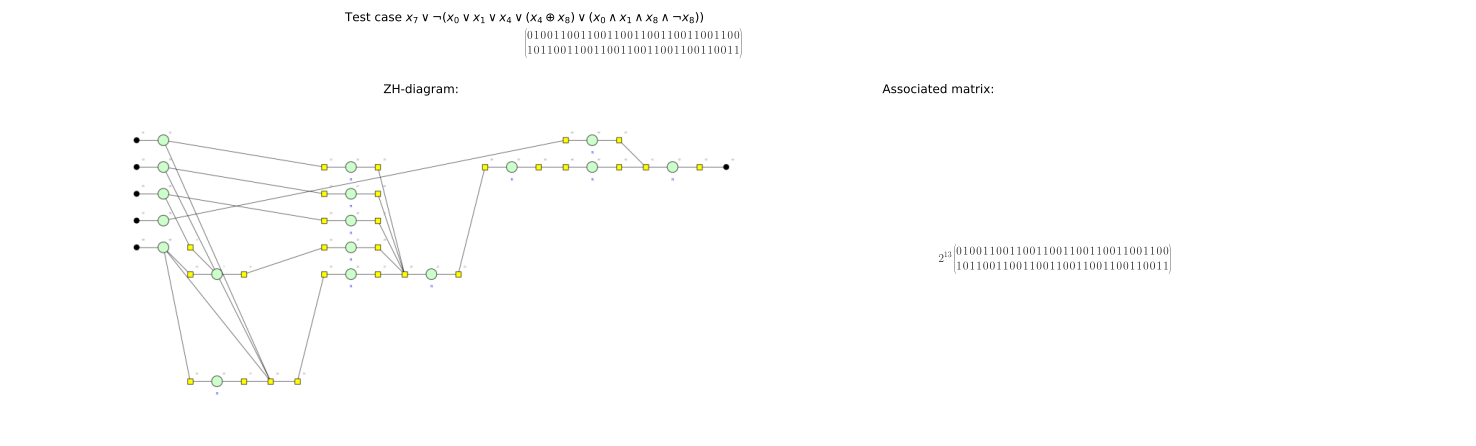

In [6]:
for i, tc in failed2[:10]:
    tc(2)
    fig = tc.draw()
    display(fig)
    plt.close(fig)